In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import sys
import os
import time
import matplotlib.pyplot as plt
from collections import deque
from datetime import datetime

# ==========================================
# 0. DEVICE CONFIGURATION (CUDA / MPS / CPU)
# ==========================================
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"CUDA GPU Detected: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("Apple MPS Backend Detected")
else:
    DEVICE = torch.device('cpu')
    print("No GPU detected — running on CPU")
print(f"Using device: {DEVICE}\n")


c:\Python311\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


No GPU detected — running on CPU
Using device: cpu



In [5]:

# ==========================================
# 1. CONFIGURATION
# ==========================================
NUM_EPISODES = 5000
BLOCK_SIZE = 10000
BATCH_SIZE = 256
GAMMA = 0.9
LEARNING_RATE = 0.0005
MEMORY_SIZE = 50000
TARGET_UPDATE_TAU = 0.005
PER_ALPHA = 0.6
PER_BETA_START = 0.4
PER_BETA_END = 1.0
PER_EPSILON = 1e-5

# ==========================================
# 2. MATH HELPERS
# ==========================================
def binary_entropy(p):
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def devetak_winter_rate(qber, f_ec=1.16):
    h2 = binary_entropy(qber)
    rate = 1.0 - h2 - f_ec * h2
    return max(0.0, rate)

# ==========================================
# 3. PRIORITIZED EXPERIENCE REPLAY
# ==========================================
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.priorities = np.zeros(capacity, dtype=np.float64)
        self.pos = 0
        self.size = 0

    def push(self, transition):
        max_prio = self.priorities[:self.size].max() if self.size > 0 else 1.0
        if self.size < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.pos] = transition
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size, beta=0.4):
        prios = self.priorities[:self.size] ** self.alpha
        probs = prios / prios.sum()

        indices = np.random.choice(self.size, batch_size, p=probs, replace=False)
        samples = [self.buffer[i] for i in indices]

        weights = (self.size * probs[indices]) ** (-beta)
        weights /= weights.max()

        return samples, indices, torch.FloatTensor(weights).to(DEVICE)

    def update_priorities(self, indices, td_errors):
        for idx, td in zip(indices, td_errors):
            self.priorities[idx] = abs(td) + PER_EPSILON

    def __len__(self):
        return self.size

# ==========================================
# 4. CONTEXT-AWARE ENVIRONMENT
# ==========================================
class QKDEnvironment:
    def __init__(self):
        self.key_pool = 1000
        self.prev_qber = 0.01
        self.avg_qber = 0.01
        self.was_turbulent = False
        self.state = None

    def get_observation(self, qber, snr, eve_present):
        delta_qber = (qber - self.prev_qber) * 10.0
        self.prev_qber = qber
        self.avg_qber = 0.8 * self.avg_qber + 0.2 * qber

        return np.array([
            qber * 2.0,
            delta_qber,
            self.avg_qber * 2.0,
            snr * 0.01,
            self.key_pool / 2000.0,
            float(eve_present),
            float(self.was_turbulent),
        ], dtype=np.float32)

    def reset(self):
        self.prev_qber = 0.01
        self.avg_qber = 0.01
        self.was_turbulent = False
        self.state = self.get_observation(0.01, 50.0, False)
        return self.state

    def step(self, action_idx):
        tag_idx = action_idx // 10
        pa_idx = action_idx % 10

        tag_lengths = [32, 64, 96, 128]
        tag_length = tag_lengths[tag_idx]
        pa_ratio = (pa_idx + 1) / 10.0

        base_qber = self.prev_qber * 0.7 + 0.01 * 0.3

        is_turbulent = False
        if random.random() < 0.15:
            is_turbulent = True
            base_qber += random.uniform(0.05, 0.10)

        base_qber = max(0.01, base_qber * 0.9)

        eve_present = random.random() < 0.15
        if eve_present:
            base_qber += 0.03

        current_qber = min(base_qber, 0.5)
        snr = 1.0 / (current_qber + 1e-6)

        secure_rate = devetak_winter_rate(current_qber)

        reward = 0.0
        final_keys = 0
        is_secure = True
        done = False

        if self.key_pool < tag_length:
            reward = -5.0
            self.key_pool = 1000
        else:
            self.key_pool -= tag_length
            is_secure = (pa_ratio <= secure_rate)

            if not is_secure:
                overshoot = pa_ratio - secure_rate
                reward = -5.0 - (overshoot * 10.0)
            elif secure_rate < 0.01:
                reward = 1.0 if pa_ratio <= 0.1 else -1.0
            else:
                raw_yield = BLOCK_SIZE * pa_ratio * (1 - current_qber)
                final_keys = int(raw_yield)
                self.key_pool += final_keys
                reward = (secure_rate * final_keys) / 500.0

                if not is_turbulent and pa_ratio > 0.6:
                    reward *= 1.3
                if is_turbulent and is_secure:
                    reward += 3.0

        if self.key_pool > 10000:
            self.key_pool = 10000

        self.was_turbulent = is_turbulent
        self.state = self.get_observation(current_qber, snr, eve_present)

        info = {
            'qber': current_qber,
            'keys': final_keys,
            'auth_cost': tag_length,
            'secure': is_secure,
            'turbulent': is_turbulent,
            'secure_rate': secure_rate,
            'pa_ratio': pa_ratio,
        }

        return self.state, reward, done, info

# ==========================================
# 5. DUELING DQN AGENT
# ==========================================
class DuelingDQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DuelingDQNAgent, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )

    def forward(self, x):
        features = self.feature(x)
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        return value + advantage - advantage.mean(dim=1, keepdim=True)

# ==========================================
# 6. TRAINING ENGINE
# ==========================================
def run_improved_simulation():
    env = QKDEnvironment()
    STATE_DIM = 7
    ACTION_DIM = 40

    policy_net = DuelingDQNAgent(STATE_DIM, ACTION_DIM).to(DEVICE)
    target_net = DuelingDQNAgent(STATE_DIM, ACTION_DIM).to(DEVICE)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPISODES, eta_min=1e-5)
    criterion = nn.SmoothL1Loss(reduction='none')

    replay_buffer = PrioritizedReplayBuffer(MEMORY_SIZE, alpha=PER_ALPHA)
    epsilon = 1.0

    episode_rewards = []
    episode_losses = []
    episode_keys = []
    episode_breaches = []

    step_count = 0
    train_start = time.time()

    print(f"Starting Improved Training: {NUM_EPISODES} Episodes on {DEVICE}")
    print("Architecture: Dueling Double DQN + PER + Soft Updates")
    print(f"Batch Size: {BATCH_SIZE}")
    print("-" * 60)

    for episode in range(1, NUM_EPISODES + 1):
        state = env.reset()
        ep_reward = 0
        ep_loss = 0
        ep_keys = 0
        ep_breaches = 0
        loss_count = 0

        beta = PER_BETA_START + (PER_BETA_END - PER_BETA_START) * (episode / NUM_EPISODES)

        for _ in range(50):
            step_count += 1

            if random.random() < epsilon:
                action = random.randint(0, ACTION_DIM - 1)
            else:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
                    q_vals = policy_net(state_t)
                    action = torch.argmax(q_vals).item()

            next_state, reward, done, info = env.step(action)
            replay_buffer.push((state, action, reward, next_state, done))

            state = next_state
            ep_reward += reward
            ep_keys += info['keys']
            if not info['secure'] and info['keys'] > 0:
                ep_breaches += 1

            if len(replay_buffer) > BATCH_SIZE:
                samples, indices, is_weights = replay_buffer.sample(BATCH_SIZE, beta)
                b_s, b_a, b_r, b_ns, b_d = zip(*samples)

                s_tensor = torch.FloatTensor(np.stack(b_s)).to(DEVICE)
                a_tensor = torch.LongTensor(b_a).unsqueeze(1).to(DEVICE)
                r_tensor = torch.FloatTensor(b_r).unsqueeze(1).to(DEVICE)
                ns_tensor = torch.FloatTensor(np.stack(b_ns)).to(DEVICE)
                d_tensor = torch.FloatTensor(b_d).unsqueeze(1).to(DEVICE)

                curr_q = policy_net(s_tensor).gather(1, a_tensor)

                with torch.no_grad():
                    best_actions = policy_net(ns_tensor).argmax(1, keepdim=True)
                    next_q = target_net(ns_tensor).gather(1, best_actions)
                    target_q = r_tensor + (GAMMA * next_q * (1 - d_tensor))

                td_errors = (curr_q - target_q).detach().cpu().squeeze().numpy()
                replay_buffer.update_priorities(indices, td_errors)

                element_loss = criterion(curr_q, target_q).squeeze()
                loss = (element_loss * is_weights).mean()

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
                optimizer.step()

                ep_loss += loss.item()
                loss_count += 1

                for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
                    target_param.data.copy_(
                        TARGET_UPDATE_TAU * policy_param.data + (1.0 - TARGET_UPDATE_TAU) * target_param.data
                    )

            if done:
                break

        epsilon = max(0.05, epsilon * 0.998)
        scheduler.step()

        episode_rewards.append(ep_reward)
        episode_losses.append(ep_loss / max(loss_count, 1))
        episode_keys.append(ep_keys)
        episode_breaches.append(ep_breaches)

        if episode % 10 == 0 or episode == NUM_EPISODES:
            progress = (episode / NUM_EPISODES) * 100
            bar_len = 30
            block = int(round(bar_len * progress / 100))
            bar = '#' * block + '-' * (bar_len - block)
            elapsed = time.time() - train_start
            eps_per_sec = episode / max(elapsed, 1e-8)
            avg_rw = np.mean(episode_rewards[-100:])
            sys.stdout.write(
                f"\r[{bar}] {progress:.1f}% | Ep: {episode} | "
                f"Eps: {epsilon:.3f} | Avg Rw: {avg_rw:.1f} | "
                f"{eps_per_sec:.1f} ep/s"
            )
            sys.stdout.flush()

    elapsed = time.time() - train_start
    print(f"\n\nTraining Complete in {elapsed:.1f}s ({elapsed / 60:.1f} min)")
    print(f"Throughput: {NUM_EPISODES / max(elapsed, 1e-8):.1f} episodes/sec")
    print("Running evaluations...\n")

    eval_episodes = 500
    eval_steps = 50

    rl_stats = {'total_keys': 0, 'failures': 0, 'breaches': 0}
    policy_net.eval()
    env = QKDEnvironment()

    for _ in range(eval_episodes):
        state = env.reset()
        for _ in range(eval_steps):
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
                q_vals = policy_net(state_t)
                action = torch.argmax(q_vals).item()

            state, _, done, info = env.step(action)
            rl_stats['total_keys'] += info['keys']
            if not info['secure'] and info['keys'] > 0:
                rl_stats['breaches'] += 1
            if info['keys'] == 0:
                rl_stats['failures'] += 1
            if done:
                break

    static_stats = {'total_keys': 0, 'failures': 0, 'breaches': 0}
    env = QKDEnvironment()
    env.reset()

    for _ in range(eval_episodes * eval_steps):
        _, _, done, info = env.step(14)
        static_stats['total_keys'] += info['keys']
        if not info['secure'] and info['keys'] > 0:
            static_stats['breaches'] += 1
        if info['keys'] == 0:
            static_stats['failures'] += 1
        if done:
            env.reset()

    print('=' * 60)
    print(f"{'IMPROVED BENCHMARK (Dueling Double DQN + PER)':^60}")
    print('=' * 60)
    print(f"{'Metric':<25} | {'Static (Fixed)':<15} | {'AI Agent':<15}")
    print('-' * 60)
    print(f"{'Total Secure Keys':<25} | {static_stats['total_keys']:<15,} | {rl_stats['total_keys']:<15,}")
    print(f"{'Security Breaches':<25} | {static_stats['breaches']:<15} | {rl_stats['breaches']:<15}")
    print(f"{'Failed/Aborted Blocks':<25} | {static_stats['failures']:<15} | {rl_stats['failures']:<15}")
    print('=' * 60)

    if static_stats['total_keys'] > 0:
        improvement = ((rl_stats['total_keys'] - static_stats['total_keys']) / static_stats['total_keys']) * 100
        print(f"\nKey Yield Improvement: {improvement:+.2f}%")
    if static_stats['failures'] > 0:
        fail_reduction = ((static_stats['failures'] - rl_stats['failures']) / static_stats['failures']) * 100
        print(f"Failure Rate Reduction: {fail_reduction:+.2f}%")

    if rl_stats['total_keys'] > static_stats['total_keys']:
        print("\n>>> SUCCESS: AI outperforms Static Baseline.")
    else:
        print("\n>>> NOTE: AI still converging — try increasing episodes.")

    return episode_rewards, episode_losses, episode_keys, episode_breaches, static_stats, rl_stats, policy_net

# ==========================================
# 9. RUN
# ==========================================
if __name__ == '__main__':
    (rewards, losses, keys, breaches,
     static_stats, rl_stats, trained_model) = run_improved_simulation()

Starting Improved Training: 5000 Episodes on cpu
Architecture: Dueling Double DQN + PER + Soft Updates
Batch Size: 256
------------------------------------------------------------
[##############################] 100.0% | Ep: 5000 | Eps: 0.050 | Avg Rw: 179.7 | 1.5 ep/s

Training Complete in 3364.9s (56.1 min)
Throughput: 1.5 episodes/sec
Running evaluations...

       IMPROVED BENCHMARK (Dueling Double DQN + PER)        
Metric                    | Static (Fixed)  | AI Agent       
------------------------------------------------------------
Total Secure Keys         | 59,807,903      | 94,847,944     
Security Breaches         | 0               | 0              
Failed/Aborted Blocks     | 12794           | 7488           

Key Yield Improvement: +58.59%
Failure Rate Reduction: +41.47%

>>> SUCCESS: AI outperforms Static Baseline.


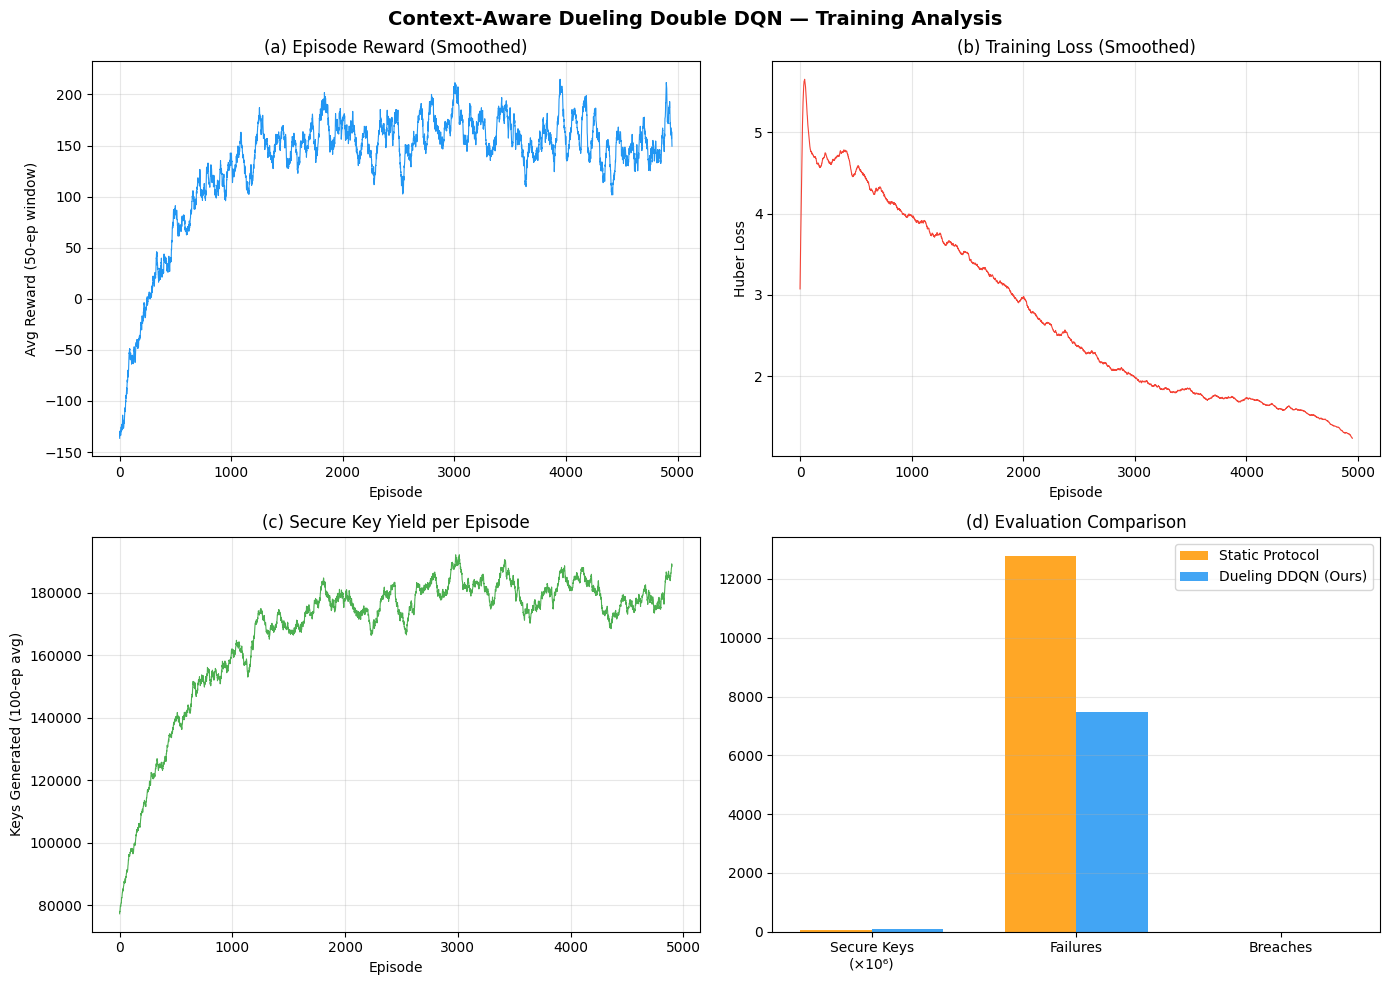

Figure saved to c:\Users\vishn\Desktop\Programs\SEM 8\RL LAB\research\outputs\improved_qkd_training.png


In [6]:
# ==========================================
# 10. TRAINING VISUALIZATIONS
# ==========================================
import os

# Ensure output directory exists
OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

def smooth(data, window=50):
    """Simple moving average for smoother plots."""
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Context-Aware Dueling Double DQN — Training Analysis", fontsize=14, fontweight='bold')

# (a) Episode Reward Curve
ax = axes[0, 0]
ax.plot(smooth(rewards, 50), color='#2196F3', linewidth=0.8)
ax.set_title("(a) Episode Reward (Smoothed)")
ax.set_xlabel("Episode")
ax.set_ylabel("Avg Reward (50-ep window)")
ax.grid(True, alpha=0.3)

# (b) Training Loss Curve
ax = axes[0, 1]
ax.plot(smooth(losses, 50), color='#F44336', linewidth=0.8)
ax.set_title("(b) Training Loss (Smoothed)")
ax.set_xlabel("Episode")
ax.set_ylabel("Huber Loss")
ax.grid(True, alpha=0.3)

# (c) Secure Keys per Episode
ax = axes[1, 0]
ax.plot(smooth(keys, 100), color='#4CAF50', linewidth=0.8)
ax.set_title("(c) Secure Key Yield per Episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Keys Generated (100-ep avg)")
ax.grid(True, alpha=0.3)

# (d) Comparative Bar Chart
ax = axes[1, 1]
metrics = ['Secure Keys\n(×10⁶)', 'Failures', 'Breaches']
static_vals = [static_stats['total_keys']/1e6, static_stats['failures'], static_stats['breaches']]
rl_vals = [rl_stats['total_keys']/1e6, rl_stats['failures'], rl_stats['breaches']]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, static_vals, width, label='Static Protocol', color='#FF9800', alpha=0.85)
bars2 = ax.bar(x + width/2, rl_vals, width, label='Dueling DDQN (Ours)', color='#2196F3', alpha=0.85)
ax.set_title("(d) Evaluation Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'improved_qkd_training.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {save_path}")

In [7]:
# ==========================================
# 11. SAVE TRAINED MODEL WEIGHTS
# ==========================================
import os, json
from datetime import datetime

SAVE_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'outputs', 'models')
os.makedirs(SAVE_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = os.path.join(SAVE_DIR, f"dueling_ddqn_qkd_{timestamp}.pth")

# Save model weights + architecture info + training config
checkpoint = {
    "model_state_dict": trained_model.cpu().state_dict(),  # Save on CPU for portability
    "architecture": "DuelingDQN",
    "state_dim": 7,
    "action_dim": 40,
    "device_trained_on": str(DEVICE),
    "training_config": {
        "num_episodes": NUM_EPISODES,
        "batch_size": BATCH_SIZE,
        "gamma": GAMMA,
        "learning_rate": LEARNING_RATE,
        "memory_size": MEMORY_SIZE,
        "target_update_tau": TARGET_UPDATE_TAU,
        "per_alpha": PER_ALPHA,
    },
    "results": {
        "rl_total_keys": rl_stats["total_keys"],
        "rl_breaches": rl_stats["breaches"],
        "rl_failures": rl_stats["failures"],
        "static_total_keys": static_stats["total_keys"],
        "static_breaches": static_stats["breaches"],
        "static_failures": static_stats["failures"],
    },
    "timestamp": timestamp,
}

torch.save(checkpoint, model_path)
print(f"Model saved to: {model_path}")
print(f"Checkpoint size: {os.path.getsize(model_path) / 1024:.1f} KB")
print(f"\nTo load later:")
print(f"  checkpoint = torch.load('{model_path}')")
print(f"  model = DuelingDQNAgent(7, 40)")
print(f"  model.load_state_dict(checkpoint['model_state_dict'])")

Model saved to: c:\Users\vishn\Desktop\Programs\SEM 8\RL LAB\research\outputs\models\dueling_ddqn_qkd_20260222_133006.pth
Checkpoint size: 216.8 KB

To load later:
  checkpoint = torch.load('c:\Users\vishn\Desktop\Programs\SEM 8\RL LAB\research\outputs\models\dueling_ddqn_qkd_20260222_133006.pth')
  model = DuelingDQNAgent(7, 40)
  model.load_state_dict(checkpoint['model_state_dict'])
